In [1]:
library(dplyr)

Warning message:
“package ‘dplyr’ was built under R version 4.3.2”

Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [ ]:
CA1_path <- "./03_Histone/Paired-Tag_DMR/output/06_H3K27ac_Allsubclass/CA1/"
CA1_files <- list.files(path = CA1_path, pattern = "\\.tmp$", full.names = TRUE)
CA1_files

[1] "/share/analysisdata/Methyl/public/TSO/yangfa/Re_analyze/03_Histone/Paired-Tag_DMR/output/06_H3K27ac_Allsubclass/CA1//Paired-Tag_H3K27ac_FC_CT.mm10.tmp"     
 [2] "/share/analysisdata/Methyl/public/TSO/yangfa/Re_analyze/03_Histone/Paired-Tag_DMR/output/06_H3K27ac_Allsubclass/CA1//Paired-Tag_H3K27ac_FC_L2_3.mm10.tmp"   
 [3] "/share/analysisdata/Methyl/public/TSO/yangfa/Re_analyze/03_Histone/Paired-Tag_DMR/output/06_H3K27ac_Allsubclass/CA1//Paired-Tag_H3K27ac_FC_L4_Rorb.mm10.tmp"
 [4] "/share/analysisdata/Methyl/public/TSO/yangfa/Re_analyze/03_Histone/Paired-Tag_DMR/output/06_H3K27ac_Allsubclass/CA1//Paired-Tag_H3K27ac_FC_L5.mm10.tmp"     
 [5] "/share/analysisdata/Methyl/public/TSO/yangfa/Re_analyze/03_Histone/Paired-Tag_DMR/output/06_H3K27ac_Allsubclass/CA1//Paired-Tag_H3K27ac_FC_L6.mm10.tmp"     
 [6] "/share/analysisdata/Methyl/public/TSO/yangfa/Re_analyze/03_Histone/Paired-Tag_DMR/output/06_H3K27ac_Allsubclass/CA1//Paired-Tag_H3K27ac_FC_NP.mm10.tmp"     
 [7] "/share/analysisdata/Methyl/public/TSO/yangfa/Re_analyze/03_Histone/Paired-Tag_DMR/output/06_H3K27ac_Allsubclass/CA1//Paired-Tag_H3K27ac_HC_CA1.mm10.tmp"    
 [8] "/share/analysisdata/Methyl/public/TSO/yangfa/Re_analyze/03_Histone/Paired-Tag_DMR/output/06_H3K27ac_Allsubclass/CA1//Paired-Tag_H3K27ac_HC_CA23.mm10.tmp"   
 [9] "/share/analysisdata/Methyl/public/TSO/yangfa/Re_analyze/03_Histone/Paired-Tag_DMR/output/06_H3K27ac_Allsubclass/CA1//Paired-Tag_H3K27ac_HC_DG.mm10.tmp"     
[10] "/share/analysisdata/Methyl/public/TSO/yangfa/Re_analyze/03_Histone/Paired-Tag_DMR/output/06_H3K27ac_Allsubclass/CA1//Paired-Tag_H3K27ac_In_CGE.mm10.tmp"    
[11] "/share/analysisdata/Methyl/public/TSO/yangfa/Re_analyze/03_Histone/Paired-Tag_DMR/output/06_H3K27ac_Allsubclass/CA1//Paired-Tag_H3K27ac_In_Pvalb.mm10.tmp"  
[12] "/share/analysisdata/Methyl/public/TSO/yangfa/Re_analyze/03_Histone/Paired-Tag_DMR/output/06_H3K27ac_Allsubclass/CA1//Paired-Tag_H3K27ac_In_Sst.mm10.tmp"

In [3]:
merged_CA1 <- NULL

In [4]:
gsub(".*(_FC_|_HC_|_In_)(.*?)\\.mm10\\.tmp$","\\2","Paired-Tag_H3K27ac_FC_CT.mm10.tmp")

[1] "CT"

In [5]:
gsub(".*(_FC_|_HC_|_In_)(.*?)\\.mm10\\.tmp$","\\2","Paired-Tag_H3K27ac_FC_L2_3.mm10.tmp")

[1] "L2_3"

In [6]:
gsub(".*(_FC_|_HC_|_In_)(.*?)\\.mm10\\.tmp$","\\2","Paired-Tag_H3K27ac_HC_DG.mm10.tmp")
gsub(".*(_FC_|_HC_|_In_)(.*?)\\.mm10\\.tmp$","\\2","Paired-Tag_H3K27ac_In_Pvalb.mm10.tmp")

[1] "DG"

[1] "Pvalb"

In [7]:
for (file in CA1_files) {

  base_name <- gsub(".*(_FC_|_HC_|_In_)(.*?)\\.mm10\\.tmp$", "\\2", basename(file))
  print(base_name)

  tmp_data <- read.table(file, header = TRUE, sep = "\t", stringsAsFactors = FALSE)

  if (!is.null(merged_CA1)) {
    if (!identical(merged_CA1[, 1], tmp_data[, 1])) {
      stop(paste("The first column in file", file, "is not identical to the previous files!"))
    }
  }

  colnames(tmp_data)[2:3] <- paste(base_name, colnames(tmp_data)[2:3], sep = "_")

  if (is.null(merged_CA1)) {
    merged_CA1 <- tmp_data
  } else {
    merged_CA1 <- cbind(merged_CA1, tmp_data[, -1])
  }
}

[1] "CT"
[1] "L2_3"
[1] "L4_Rorb"
[1] "L5"
[1] "L6"
[1] "NP"
[1] "CA1"
[1] "CA23"
[1] "DG"
[1] "CGE"
[1] "Pvalb"
[1] "Sst"


In [8]:
merged_CA1

hyperDHMR,CT_signal_sum,CT_signal_sum_log10,L2_3_signal_sum,L2_3_signal_sum_log10,L4_Rorb_signal_sum,L4_Rorb_signal_sum_log10,L5_signal_sum,L5_signal_sum_log10,L6_signal_sum,⋯,CA23_signal_sum,CA23_signal_sum_log10,DG_signal_sum,DG_signal_sum_log10,CGE_signal_sum,CGE_signal_sum_log10,Pvalb_signal_sum,Pvalb_signal_sum_log10,Sst_signal_sum,Sst_signal_sum_log10
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:4000851-4001851,0.0000,0.000000,0.000000,0.0000000,0.000000,0.0000000,0.000000,0.0000000,0.0000,⋯,0.0000,0.000000,0.00000,0.000000,0.00000,0.000000,0.0000,0.000000,0.00000,0.000000
chr1:4794017-4795017,0.0000,0.000000,0.000000,0.0000000,0.000000,0.0000000,0.000000,0.0000000,0.0000,⋯,0.0000,0.000000,0.00000,0.000000,0.00000,0.000000,0.0000,0.000000,0.00000,0.000000
chr1:4947085-4948085,0.0000,0.000000,146.083920,2.1675652,0.000000,0.0000000,0.000000,0.0000000,1099.8348,⋯,0.0000,0.000000,0.00000,0.000000,0.00000,0.000000,0.0000,0.000000,0.00000,0.000000
chr1:5336791-5337791,1335.0746,3.125831,2.629512,0.5598482,2.714652,0.5699181,0.000000,0.0000000,164.9754,⋯,0.0000,0.000000,0.00000,0.000000,0.00000,0.000000,0.0000,0.000000,0.00000,0.000000
chr1:5745992-5746992,0.0000,0.000000,0.000000,0.0000000,0.000000,0.0000000,0.000000,0.0000000,0.0000,⋯,0.0000,0.000000,0.00000,0.000000,0.00000,0.000000,0.0000,0.000000,0.00000,0.000000
chr1:5825616-5826616,157.5203,2.200085,0.000000,0.0000000,0.000000,0.0000000,0.000000,0.0000000,0.0000,⋯,0.0000,0.000000,0.00000,0.000000,587.21056,2.769533,0.0000,0.000000,0.00000,0.000000
chr1:6177024-6178024,0.0000,0.000000,146.083920,2.1675652,0.000000,0.0000000,56.406016,1.7589574,518.7908,⋯,0.0000,0.000000,0.00000,0.000000,0.00000,0.000000,0.0000,0.000000,0.00000,0.000000
chr1:7060591-7061591,0.0000,0.000000,292.167200,2.4671154,266.036678,2.4265709,115.945594,2.0679839,0.0000,⋯,0.0000,0.000000,433.80512,2.638295,0.00000,0.000000,0.0000,0.000000,0.00000,0.000000
chr1:8211551-8212551,0.0000,0.000000,0.000000,0.0000000,241.906358,2.3854389,0.000000,0.0000000,0.0000,⋯,0.0000,0.000000,0.00000,0.000000,0.00000,0.000000,0.0000,0.000000,0.00000,0.000000


In [9]:
merged_CA1 <- merged_CA1[, c(1, grep("signal_sum_log10", colnames(merged_CA1)))]

merged_CA1

hyperDHMR,CT_signal_sum_log10,L2_3_signal_sum_log10,L4_Rorb_signal_sum_log10,L5_signal_sum_log10,L6_signal_sum_log10,NP_signal_sum_log10,CA1_signal_sum_log10,CA23_signal_sum_log10,DG_signal_sum_log10,CGE_signal_sum_log10,Pvalb_signal_sum_log10,Sst_signal_sum_log10
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:4000851-4001851,0.000000,0.0000000,0.0000000,0.0000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:4794017-4795017,0.000000,0.0000000,0.0000000,0.0000000,0.000000,0.00000,2.849732,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:4947085-4948085,0.000000,2.1675652,0.0000000,0.0000000,3.041722,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:5336791-5337791,3.125831,0.5598482,0.5699181,0.0000000,2.220044,0.00000,2.626956,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:5745992-5746992,0.000000,0.0000000,0.0000000,0.0000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:5825616-5826616,2.200085,0.0000000,0.0000000,0.0000000,0.000000,0.00000,0.000000,0.000000,0.000000,2.769533,0.000000,0.000000
chr1:6177024-6178024,0.000000,2.1675652,0.0000000,1.7589574,2.715829,0.00000,1.033019,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:7060591-7061591,0.000000,2.4671154,2.4265709,2.0679839,0.000000,0.00000,2.595750,0.000000,2.638295,0.000000,0.000000,0.000000
chr1:8211551-8212551,0.000000,0.0000000,2.3854389,0.0000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [10]:
library(tidyverse)

Warning message:
“package ‘tidyverse’ was built under R version 4.3.3”
Warning message:
“package ‘ggplot2’ was built under R version 4.3.3”
Warning message:
“package ‘readr’ was built under R version 4.3.3”
Warning message:
“package ‘stringr’ was built under R version 4.3.2”
Warning message:
“package ‘forcats’ was built under R version 4.3.3”
── Attaching core tidyverse packages ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.0     ✔ readr     2.1.5
✔ ggplot2   3.5.2     ✔ stringr   1.5.1
✔ lubridate 1.9.3     ✔ tibble    3.2.1
✔ purrr     1.0.2     ✔ tidyr     1.3.0
── Conflicts ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all

In [11]:
merged_CA1 <- merged_CA1 %>% column_to_rownames("hyperDHMR")
merged_CA1

,CT_signal_sum_log10,L2_3_signal_sum_log10,L4_Rorb_signal_sum_log10,L5_signal_sum_log10,L6_signal_sum_log10,NP_signal_sum_log10,CA1_signal_sum_log10,CA23_signal_sum_log10,DG_signal_sum_log10,CGE_signal_sum_log10,Pvalb_signal_sum_log10,Sst_signal_sum_log10
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:4000851-4001851,0.000000,0.0000000,0.0000000,0.0000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:4794017-4795017,0.000000,0.0000000,0.0000000,0.0000000,0.000000,0.00000,2.849732,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:4947085-4948085,0.000000,2.1675652,0.0000000,0.0000000,3.041722,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:5336791-5337791,3.125831,0.5598482,0.5699181,0.0000000,2.220044,0.00000,2.626956,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:5745992-5746992,0.000000,0.0000000,0.0000000,0.0000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:5825616-5826616,2.200085,0.0000000,0.0000000,0.0000000,0.000000,0.00000,0.000000,0.000000,0.000000,2.769533,0.000000,0.000000
chr1:6177024-6178024,0.000000,2.1675652,0.0000000,1.7589574,2.715829,0.00000,1.033019,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:7060591-7061591,0.000000,2.4671154,2.4265709,2.0679839,0.000000,0.00000,2.595750,0.000000,2.638295,0.000000,0.000000,0.000000
chr1:8211551-8212551,0.000000,0.0000000,2.3854389,0.0000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [12]:
colnames(merged_CA1) <- gsub("_signal_sum_log10$","",colnames(merged_CA1))
merged_CA1

,CT,L2_3,L4_Rorb,L5,L6,NP,CA1,CA23,DG,CGE,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:4000851-4001851,0.000000,0.0000000,0.0000000,0.0000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:4794017-4795017,0.000000,0.0000000,0.0000000,0.0000000,0.000000,0.00000,2.849732,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:4947085-4948085,0.000000,2.1675652,0.0000000,0.0000000,3.041722,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:5336791-5337791,3.125831,0.5598482,0.5699181,0.0000000,2.220044,0.00000,2.626956,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:5745992-5746992,0.000000,0.0000000,0.0000000,0.0000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:5825616-5826616,2.200085,0.0000000,0.0000000,0.0000000,0.000000,0.00000,0.000000,0.000000,0.000000,2.769533,0.000000,0.000000
chr1:6177024-6178024,0.000000,2.1675652,0.0000000,1.7589574,2.715829,0.00000,1.033019,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:7060591-7061591,0.000000,2.4671154,2.4265709,2.0679839,0.000000,0.00000,2.595750,0.000000,2.638295,0.000000,0.000000,0.000000
chr1:8211551-8212551,0.000000,0.0000000,2.3854389,0.0000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [13]:
colnames(merged_CA1)[which(colnames(merged_CA1) %in% "L4_Rorb")] <- "L4"

In [14]:
merged_CA1

,CT,L2_3,L4,L5,L6,NP,CA1,CA23,DG,CGE,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:4000851-4001851,0.000000,0.0000000,0.0000000,0.0000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:4794017-4795017,0.000000,0.0000000,0.0000000,0.0000000,0.000000,0.00000,2.849732,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:4947085-4948085,0.000000,2.1675652,0.0000000,0.0000000,3.041722,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:5336791-5337791,3.125831,0.5598482,0.5699181,0.0000000,2.220044,0.00000,2.626956,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:5745992-5746992,0.000000,0.0000000,0.0000000,0.0000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:5825616-5826616,2.200085,0.0000000,0.0000000,0.0000000,0.000000,0.00000,0.000000,0.000000,0.000000,2.769533,0.000000,0.000000
chr1:6177024-6178024,0.000000,2.1675652,0.0000000,1.7589574,2.715829,0.00000,1.033019,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:7060591-7061591,0.000000,2.4671154,2.4265709,2.0679839,0.000000,0.00000,2.595750,0.000000,2.638295,0.000000,0.000000,0.000000
chr1:8211551-8212551,0.000000,0.0000000,2.3854389,0.0000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [15]:
merged_CA1$merge_L5 <- (merged_CA1$L5+merged_CA1$L6)/2
merged_CA1 <- merged_CA1 %>% dplyr::select(-c(L5,L6))
colnames(merged_CA1)[which(colnames(merged_CA1) == "merge_L5")] <- "L5"
merged_CA1

,CT,L2_3,L4,NP,CA1,CA23,DG,CGE,Pvalb,Sst,L5
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:4000851-4001851,0.000000,0.0000000,0.0000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000000
chr1:4794017-4795017,0.000000,0.0000000,0.0000000,0.00000,2.849732,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000000
chr1:4947085-4948085,0.000000,2.1675652,0.0000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.5208611
chr1:5336791-5337791,3.125831,0.5598482,0.5699181,0.00000,2.626956,0.000000,0.000000,0.000000,0.000000,0.000000,1.1100219
chr1:5745992-5746992,0.000000,0.0000000,0.0000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000000
chr1:5825616-5826616,2.200085,0.0000000,0.0000000,0.00000,0.000000,0.000000,0.000000,2.769533,0.000000,0.000000,0.0000000
chr1:6177024-6178024,0.000000,2.1675652,0.0000000,0.00000,1.033019,0.000000,0.000000,0.000000,0.000000,0.000000,2.2373930
chr1:7060591-7061591,0.000000,2.4671154,2.4265709,0.00000,2.595750,0.000000,2.638295,0.000000,0.000000,0.000000,1.0339919
chr1:8211551-8212551,0.000000,0.0000000,2.3854389,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000000


In [16]:
# celltype_order <- c("L2_3","L4","L5","L6","CA1","CA23","NP","CT","DG","CGE","Pvalb","Sst")
celltype_order <- c("L2_3","L4","L5","CA1","CA23","NP","CT","DG","CGE","Pvalb","Sst")
celltype_order

[1] "L2_3"  "L4"    "L5"    "CA1"   "CA23"  "NP"    "CT"    "DG"    "CGE"  
[10] "Pvalb" "Sst"

In [17]:
merged_CA1 <- merged_CA1[,celltype_order]
merged_CA1

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:4000851-4001851,0.0000000,0.0000000,0.0000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:4794017-4795017,0.0000000,0.0000000,0.0000000,2.849732,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:4947085-4948085,2.1675652,0.0000000,1.5208611,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:5336791-5337791,0.5598482,0.5699181,1.1100219,2.626956,0.000000,0.00000,3.125831,0.000000,0.000000,0.000000,0.000000
chr1:5745992-5746992,0.0000000,0.0000000,0.0000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:5825616-5826616,0.0000000,0.0000000,0.0000000,0.000000,0.000000,0.00000,2.200085,0.000000,2.769533,0.000000,0.000000
chr1:6177024-6178024,2.1675652,0.0000000,2.2373930,1.033019,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:7060591-7061591,2.4671154,2.4265709,1.0339919,2.595750,0.000000,0.00000,0.000000,2.638295,0.000000,0.000000,0.000000
chr1:8211551-8212551,0.0000000,2.3854389,0.0000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000


In [18]:
colMeans(merged_CA1) %>% data.frame() %>% t()

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
.,0.7530246,0.5774471,0.4784633,0.8278466,0.5343843,0.2107115,0.5034959,0.6624258,0.3909133,0.2842445,0.3188867


In [19]:
process_files <- function(input_path, pattern = "\\.tmp$", celltype_order) {
  files <- list.files(path = input_path, pattern = pattern, full.names = TRUE)
  merged_data <- NULL

  for (file in files) {
    base_name <- gsub(".*(_FC_|_HC_|_In_)(.*?)\\.mm10\\.tmp$", "\\2", basename(file))
    print(base_name)

    tmp_data <- read.table(file, header = TRUE, sep = "\t", stringsAsFactors = FALSE)

    if (!is.null(merged_data)) {
      if (!identical(merged_data[, 1], tmp_data[, 1])) {
        stop(paste("The first column in file", file, "is not identical to the previous files!"))
      }
    }

    colnames(tmp_data)[2:3] <- paste(base_name, colnames(tmp_data)[2:3], sep = "_")

    if (is.null(merged_data)) {
      merged_data <- tmp_data
    } else {
      merged_data <- cbind(merged_data, tmp_data[, -1])
    }
  }

  merged_data <- merged_data[, c(1, grep("signal_sum_log10", colnames(merged_data)))]
  merged_data <- merged_data %>% column_to_rownames("hyperDHMR")
  colnames(merged_data) <- gsub("_signal_sum_log10$", "", colnames(merged_data))

  colnames(merged_data)[which(colnames(merged_data) %in% "L4_Rorb")] <- "L4"

  merged_data$merge_L5 <- (merged_data$L5+merged_data$L6)/2
  merged_data <- merged_data %>% dplyr::select(-c(L5,L6))
  colnames(merged_data)[which(colnames(merged_data) == "merge_L5")] <- "L5"

  celltype_order <- c("L2_3", "L4", "L5", "CA1", "CA23", "NP", "CT", "DG", "CGE", "Pvalb", "Sst")

  merged_data <- merged_data[, celltype_order]
  
  return(merged_data)
}

In [ ]:
H3K27ac_path <- "./03_Histone/Paired-Tag_DMR/output/06_H3K27ac_Allsubclass/"

In [21]:
subdirs <- list.dirs(path = H3K27ac_path, full.names = TRUE, recursive = FALSE)
subdirs

[1] "/share/analysisdata/Methyl/public/TSO/yangfa/Re_analyze/03_Histone/Paired-Tag_DMR/output/06_H3K27ac_Allsubclass//CA1"  
 [2] "/share/analysisdata/Methyl/public/TSO/yangfa/Re_analyze/03_Histone/Paired-Tag_DMR/output/06_H3K27ac_Allsubclass//CA23" 
 [3] "/share/analysisdata/Methyl/public/TSO/yangfa/Re_analyze/03_Histone/Paired-Tag_DMR/output/06_H3K27ac_Allsubclass//CT"   
 [4] "/share/analysisdata/Methyl/public/TSO/yangfa/Re_analyze/03_Histone/Paired-Tag_DMR/output/06_H3K27ac_Allsubclass//DG"   
 [5] "/share/analysisdata/Methyl/public/TSO/yangfa/Re_analyze/03_Histone/Paired-Tag_DMR/output/06_H3K27ac_Allsubclass//L2_3" 
 [6] "/share/analysisdata/Methyl/public/TSO/yangfa/Re_analyze/03_Histone/Paired-Tag_DMR/output/06_H3K27ac_Allsubclass//L4_5" 
 [7] "/share/analysisdata/Methyl/public/TSO/yangfa/Re_analyze/03_Histone/Paired-Tag_DMR/output/06_H3K27ac_Allsubclass//L5"   
 [8] "/share/analysisdata/Methyl/public/TSO/yangfa/Re_analyze/03_Histone/Paired-Tag_DMR/output/06_H3K27ac_Allsubclass//Lamp5"
 [9] "/share/analysisdata/Methyl/public/TSO/yangfa/Re_analyze/03_Histone/Paired-Tag_DMR/output/06_H3K27ac_Allsubclass//NP"   
[10] "/share/analysisdata/Methyl/public/TSO/yangfa/Re_analyze/03_Histone/Paired-Tag_DMR/output/06_H3K27ac_Allsubclass//Pvalb"
[11] "/share/analysisdata/Methyl/public/TSO/yangfa/Re_analyze/03_Histone/Paired-Tag_DMR/output/06_H3K27ac_Allsubclass//Sncg" 
[12] "/share/analysisdata/Methyl/public/TSO/yangfa/Re_analyze/03_Histone/Paired-Tag_DMR/output/06_H3K27ac_Allsubclass//Sst"

In [22]:
basename(subdirs)

[1] "CA1"   "CA23"  "CT"    "DG"    "L2_3"  "L4_5"  "L5"    "Lamp5" "NP"   
[10] "Pvalb" "Sncg"  "Sst"

In [ ]:
L2_3 <- process_files('./03_Histone/Paired-Tag_DMR/output/06_H3K27ac_Allsubclass/L2_3', 
                      pattern = "\\.tmp$", celltype_order = celltype_order)

L2_3

[1] "CT"
[1] "L2_3"
[1] "L4_Rorb"
[1] "L5"
[1] "L6"
[1] "NP"
[1] "CA1"
[1] "CA23"
[1] "DG"
[1] "CGE"
[1] "Pvalb"
[1] "Sst"


,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:6943646-6944646,0.000000,0.000000,0.0000000,0.000000,0.000000,0.000000,0.000000,1.702326,0.000000,0.000000,0.000000
chr1:9780815-9781815,1.763222,0.000000,2.2425169,2.029619,2.643218,0.000000,0.000000,2.377381,0.000000,0.000000,0.000000
chr1:20575278-20576278,0.000000,0.000000,0.0000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:31350491-31351491,0.000000,0.000000,0.0000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.059522,0.000000,0.000000
chr1:31956491-31957491,0.000000,0.000000,0.0000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:35665086-35666086,2.161484,0.000000,0.0000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:40205252-40206252,2.422483,0.000000,0.0000000,0.000000,0.000000,3.028136,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:41656765-41657765,0.000000,0.000000,0.0000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:41760547-41761547,2.058277,0.000000,0.0000000,2.677435,0.000000,2.520580,2.449321,0.000000,0.000000,0.000000,2.703673


In [24]:
L2_3_mean <- colMeans(L2_3) %>% data.frame() %>% t()
rownames(L2_3_mean) <- "L2_3"
L2_3_mean

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
L2_3,1.376429,0.6803317,0.6551297,0.4809973,0.3814886,0.2050757,0.5529783,0.5957269,0.4448633,0.2696288,0.3692199


In [ ]:
L4_5 <- process_files('./03_Histone/Paired-Tag_DMR/output/06_H3K27ac_Allsubclass/L4_5', 
                      pattern = "\\.tmp$", celltype_order = celltype_order)

L4_5

[1] "CT"
[1] "L2_3"
[1] "L4_Rorb"
[1] "L5"
[1] "L6"
[1] "NP"
[1] "CA1"
[1] "CA23"
[1] "DG"
[1] "CGE"
[1] "Pvalb"
[1] "Sst"


,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:3931138-3932138,0.000000,0.000000,0.0000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:7536517-7537517,2.494781,0.000000,1.0887981,0.000000,0.000000,0.000000,0.000000,2.339915,2.093026,0.000000,0.000000
chr1:9794519-9795519,2.709518,0.000000,1.5566339,2.611633,0.000000,0.000000,0.000000,0.000000,0.000000,2.738005,0.000000
chr1:14839073-14840073,0.000000,0.000000,0.0000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:14914779-14915779,0.000000,0.000000,0.0000000,2.482406,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:18962969-18963969,2.400344,2.708979,1.1061678,0.000000,0.000000,2.262814,2.441947,0.000000,2.372426,2.488360,0.000000
chr1:22023298-22024298,0.000000,0.000000,0.0000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:24906164-24907164,2.914558,0.000000,1.1759302,0.000000,2.953598,0.000000,0.000000,0.000000,0.000000,0.000000,2.703673
chr1:27500435-27501435,2.087248,0.000000,1.4668149,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [26]:
L4_5_mean <- colMeans(L4_5) %>% data.frame() %>% t()
rownames(L4_5_mean) <- "L4_5"
L4_5_mean

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
L4_5,1.156955,1.137772,0.8047273,0.4015107,0.3805197,0.2464978,0.5415682,0.5445659,0.4315123,0.3974421,0.355935


In [ ]:
L5 <- process_files('./03_Histone/Paired-Tag_DMR/output/06_H3K27ac_Allsubclass/L5', 
                      pattern = "\\.tmp$", celltype_order = celltype_order)

L5

[1] "CT"
[1] "L2_3"
[1] "L4_Rorb"
[1] "L5"
[1] "L6"
[1] "NP"
[1] "CA1"
[1] "CA23"
[1] "DG"
[1] "CGE"
[1] "Pvalb"
[1] "Sst"


,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:9892852-9893852,0.000000,0.000000,0.000000,0.0000000,0.000000,0.000000,1.788186,0.000000,0.000000,0.0000000,0.000000
chr1:11320903-11321903,0.000000,0.000000,1.175281,0.0000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000000,0.000000
chr1:15848796-15849796,2.810696,2.658828,3.155589,0.0000000,0.000000,3.352144,2.909711,2.333743,0.000000,0.0000000,3.004274
chr1:20499848-20500848,0.000000,0.000000,1.311719,0.0000000,0.000000,0.000000,2.263380,0.000000,0.000000,0.0000000,2.513034
chr1:22220457-22221457,0.000000,0.000000,1.060560,0.0000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000000,0.000000
chr1:22315425-22316425,2.456158,2.135873,0.000000,0.0000000,0.000000,3.219975,0.000000,0.000000,2.680610,0.0000000,2.444738
chr1:26778141-26779141,0.000000,1.126026,0.000000,0.0000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000000,0.000000
chr1:27662663-27663663,1.287949,0.000000,0.000000,0.0000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000000,0.000000
chr1:27663831-27664831,2.475262,0.000000,1.537217,0.0000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000000,0.000000


In [28]:
L5_mean <- colMeans(L5) %>% data.frame() %>% t()
rownames(L5_mean) <- "L5"
L5_mean

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
L5,0.9791836,0.7466564,0.8379659,0.47599,0.4092733,0.3162556,0.8378457,0.4996564,0.4780975,0.3092028,0.3787727


In [ ]:
CA1 <- process_files('./03_Histone/Paired-Tag_DMR/output/06_H3K27ac_Allsubclass/CA1', 
                      pattern = "\\.tmp$", celltype_order = celltype_order)

CA1

[1] "CT"
[1] "L2_3"
[1] "L4_Rorb"
[1] "L5"
[1] "L6"
[1] "NP"
[1] "CA1"
[1] "CA23"
[1] "DG"
[1] "CGE"
[1] "Pvalb"
[1] "Sst"


,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:4000851-4001851,0.0000000,0.0000000,0.0000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:4794017-4795017,0.0000000,0.0000000,0.0000000,2.849732,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:4947085-4948085,2.1675652,0.0000000,1.5208611,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:5336791-5337791,0.5598482,0.5699181,1.1100219,2.626956,0.000000,0.00000,3.125831,0.000000,0.000000,0.000000,0.000000
chr1:5745992-5746992,0.0000000,0.0000000,0.0000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:5825616-5826616,0.0000000,0.0000000,0.0000000,0.000000,0.000000,0.00000,2.200085,0.000000,2.769533,0.000000,0.000000
chr1:6177024-6178024,2.1675652,0.0000000,2.2373930,1.033019,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:7060591-7061591,2.4671154,2.4265709,1.0339919,2.595750,0.000000,0.00000,0.000000,2.638295,0.000000,0.000000,0.000000
chr1:8211551-8212551,0.0000000,2.3854389,0.0000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000


In [30]:
CA1_mean <- colMeans(CA1) %>% data.frame() %>% t()
rownames(CA1_mean) <- "CA1"
CA1_mean

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
CA1,0.7530246,0.5774471,0.4784633,0.8278466,0.5343843,0.2107115,0.5034959,0.6624258,0.3909133,0.2842445,0.3188867


In [ ]:
CA23 <- process_files('./03_Histone/Paired-Tag_DMR/output/06_H3K27ac_Allsubclass/CA23', 
                      pattern = "\\.tmp$", celltype_order = celltype_order)

CA23

[1] "CT"
[1] "L2_3"
[1] "L4_Rorb"
[1] "L5"
[1] "L6"
[1] "NP"
[1] "CA1"
[1] "CA23"
[1] "DG"
[1] "CGE"
[1] "Pvalb"
[1] "Sst"


,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:4065207-4066207,0.0000000,0.000000,0.2046992,0.000000,2.140330,0.000000,0.000000,0.000000,0.000000,0,0.000000
chr1:4072107-4073107,0.0000000,0.000000,0.0000000,0.000000,3.130455,0.000000,0.000000,0.000000,0.000000,0,0.000000
chr1:4118129-4119129,0.7190348,2.128140,0.0000000,0.000000,0.000000,3.051307,0.000000,2.377381,2.566938,0,0.000000
chr1:4258756-4259756,0.0000000,0.000000,0.0000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0,0.000000
chr1:4342915-4343915,0.0000000,0.000000,0.0000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0,0.000000
chr1:4354000-4355000,0.0000000,0.000000,1.0263789,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0,0.000000
chr1:4651433-4652433,0.0000000,0.000000,0.0000000,0.000000,2.681713,2.275944,2.472889,0.000000,0.000000,0,0.000000
chr1:5318811-5319811,0.0000000,0.000000,0.0000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0,0.000000
chr1:5690821-5691821,0.0000000,0.000000,0.0000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0,0.000000


In [32]:
CA23_mean <- colMeans(CA23) %>% data.frame() %>% t()
rownames(CA23_mean) <- "CA23"
CA23_mean

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
CA23,0.8351774,0.5907997,0.5632122,0.6125765,0.6750242,0.2734543,0.575323,0.7468545,0.5358159,0.4105121,0.4253888


In [ ]:
NP <- process_files('./03_Histone/Paired-Tag_DMR/output/06_H3K27ac_Allsubclass/NP', 
                      pattern = "\\.tmp$", celltype_order = celltype_order)

NP

[1] "CT"
[1] "L2_3"
[1] "L4_Rorb"
[1] "L5"
[1] "L6"
[1] "NP"
[1] "CA1"
[1] "CA23"
[1] "DG"
[1] "CGE"
[1] "Pvalb"
[1] "Sst"


,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:6845070-6846070,0.000000,2.467726,1.0545958,3.077801,0.000000,0.000000,0.000000,2.3642093,2.566938,0.000000,0.000000
chr1:11028780-11029780,0.000000,0.000000,0.0000000,0.000000,0.000000,0.000000,0.000000,2.5470515,0.000000,0.000000,0.000000
chr1:11614937-11615937,0.000000,0.000000,0.0000000,0.000000,0.000000,0.000000,2.104264,0.0000000,0.000000,0.000000,0.000000
chr1:11704039-11705039,2.570434,2.290589,1.4233211,2.850232,2.308262,0.000000,2.455672,0.0000000,2.458254,0.000000,0.000000
chr1:12334597-12335597,2.254805,0.000000,0.0000000,0.000000,2.386745,0.000000,0.000000,0.0000000,2.272237,0.000000,0.000000
chr1:14916069-14917069,0.000000,0.000000,0.0000000,0.000000,0.000000,0.000000,0.000000,2.6465166,0.000000,0.000000,0.000000
chr1:15504363-15505363,3.101861,2.767345,2.9944591,2.883907,2.441295,0.000000,2.444727,0.0000000,2.566938,0.000000,0.000000
chr1:16980355-16981355,2.623519,2.202366,2.3416219,0.000000,2.295796,0.000000,2.276502,2.2862932,0.000000,0.000000,0.000000
chr1:17551156-17552156,0.000000,0.000000,0.0000000,0.000000,0.000000,0.000000,0.000000,0.0000000,0.000000,0.000000,0.000000


In [34]:
NP_mean <- colMeans(NP) %>% data.frame() %>% t()
rownames(NP_mean) <- "NP"
NP_mean

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
NP,1.128384,0.894931,0.8542834,0.7680926,0.6714674,0.5412973,0.9592995,0.8706204,0.7482628,0.6198826,0.6875633


In [ ]:
CT <- process_files('./03_Histone/Paired-Tag_DMR/output/06_H3K27ac_Allsubclass/CT', 
                      pattern = "\\.tmp$", celltype_order = celltype_order)

CT

[1] "CT"
[1] "L2_3"
[1] "L4_Rorb"
[1] "L5"
[1] "L6"
[1] "NP"
[1] "CA1"
[1] "CA23"
[1] "DG"
[1] "CGE"
[1] "Pvalb"
[1] "Sst"


,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:5417353-5418353,0.0000000,0.000000,0.0000000,0.000000,0.000000,0.000000,2.8478873,0.0000000,0.000000,0.000000,0.000000
chr1:9594969-9595969,0.0000000,0.000000,0.0000000,0.000000,2.381586,0.000000,0.0000000,0.0000000,0.000000,0.000000,0.000000
chr1:10605311-10606311,0.6246789,0.000000,0.2696744,0.000000,1.062563,0.000000,0.8758713,0.0000000,0.000000,0.000000,0.000000
chr1:11728492-11729492,0.0000000,0.000000,0.0000000,0.000000,0.000000,0.000000,0.0000000,0.0000000,0.000000,0.000000,0.000000
chr1:12280996-12281996,2.4028604,0.000000,2.6891455,0.000000,2.019435,0.000000,2.9373094,0.0000000,0.000000,2.590806,0.479687
chr1:14647119-14648119,0.0000000,0.000000,0.0000000,0.000000,0.000000,0.000000,0.0000000,0.0000000,0.000000,0.000000,0.000000
chr1:17950689-17951689,0.0000000,0.000000,0.0000000,0.000000,0.000000,0.000000,0.0000000,0.0000000,0.000000,0.000000,0.000000
chr1:20849555-20850555,0.0000000,0.000000,0.0000000,2.591686,0.000000,0.000000,1.9743680,0.0000000,0.000000,1.700202,0.000000
chr1:21273238-21274238,2.7667536,0.000000,3.0459233,0.000000,0.000000,3.456248,2.8445905,0.0000000,0.000000,2.938016,0.000000


In [36]:
CT_mean <- colMeans(CT) %>% data.frame() %>% t()
rownames(CT_mean) <- "CT"
CT_mean

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
CT,0.9613789,0.7715474,0.775091,0.5673558,0.5930086,0.3638673,1.206335,0.6812668,0.5935908,0.4845609,0.5184566


In [ ]:
DG <- process_files('./03_Histone/Paired-Tag_DMR/output/06_H3K27ac_Allsubclass/DG', 
                      pattern = "\\.tmp$", celltype_order = celltype_order)

DG

[1] "CT"
[1] "L2_3"
[1] "L4_Rorb"
[1] "L5"
[1] "L6"
[1] "NP"
[1] "CA1"
[1] "CA23"
[1] "DG"
[1] "CGE"
[1] "Pvalb"
[1] "Sst"


,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:6862813-6863813,0.000000,0.000000,1.324549,0.000000,0.000000,0.000000,0.000000,3.111092,0.000000,0.000000,0.000000
chr1:13910825-13911825,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:16814367-16815367,3.024331,0.000000,1.189952,3.230960,2.583403,0.000000,3.216764,2.843786,0.000000,0.000000,0.000000
chr1:16867816-16868816,0.000000,0.000000,0.000000,1.842170,0.000000,0.000000,0.000000,2.108120,0.000000,0.000000,0.000000
chr1:17029988-17030988,0.000000,2.341196,0.000000,0.000000,0.000000,0.000000,2.467664,3.165715,0.000000,0.000000,0.000000
chr1:20272407-20273407,2.640686,2.480910,0.000000,0.000000,0.000000,0.000000,0.000000,2.335175,0.000000,0.000000,0.000000
chr1:30120438-30121438,0.000000,0.000000,0.000000,2.188580,0.000000,0.000000,0.000000,0.000000,0.000000,2.721212,0.000000
chr1:30587191-30588191,2.274803,0.000000,2.972039,0.000000,1.649690,0.000000,2.165483,2.182557,2.593402,0.000000,0.000000
chr1:31097496-31098496,0.000000,0.000000,2.532109,2.102563,2.679976,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [38]:
DG_mean <- colMeans(DG) %>% data.frame() %>% t()
rownames(DG_mean) <- "DG"
DG_mean

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
DG,1.086405,0.8540406,0.8293104,0.7635597,0.7595284,0.393345,0.8229563,1.172038,0.735374,0.6130111,0.6484391


In [ ]:
Lamp5 <- process_files('./03_Histone/Paired-Tag_DMR/output/06_H3K27ac_Allsubclass/Lamp5', 
                      pattern = "\\.tmp$", celltype_order = celltype_order)

Lamp5

[1] "CT"
[1] "L2_3"
[1] "L4_Rorb"
[1] "L5"
[1] "L6"
[1] "NP"
[1] "CA1"
[1] "CA23"
[1] "DG"
[1] "CGE"
[1] "Pvalb"
[1] "Sst"


,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:3116806-3117806,0.000000,3.255688,0.0000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.13547,0.000000
chr1:3290864-3291864,2.509160,0.000000,0.0000000,0.000000,0.000000,0.000000,3.002824,0.000000,2.267085,0.00000,0.000000
chr1:3510333-3511333,1.808889,2.547405,2.0530856,2.248511,0.000000,3.918205,2.958192,0.000000,2.132454,0.00000,3.329973
chr1:3732916-3733916,0.000000,0.000000,0.0000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000
chr1:3889972-3890972,0.000000,0.000000,0.0000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000
chr1:4330502-4331502,0.000000,0.000000,1.0255171,0.000000,0.000000,0.000000,0.000000,0.000000,2.464878,0.00000,0.000000
chr1:4338706-4339706,0.000000,0.000000,0.0000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000
chr1:5537626-5538626,0.934315,0.000000,0.0000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000
chr1:6366013-6367013,0.000000,0.000000,0.0000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000


In [40]:
Lamp5_mean <- colMeans(Lamp5) %>% data.frame() %>% t()
rownames(Lamp5_mean) <- "Lamp5"
Lamp5_mean

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
Lamp5,0.7288381,0.5340942,0.4963876,0.4689996,0.4251952,0.2320039,0.5207082,0.573324,0.669282,0.3846316,0.4248726


In [ ]:
Sncg <- process_files('./03_Histone/Paired-Tag_DMR/output/06_H3K27ac_Allsubclass/Sncg', 
                      pattern = "\\.tmp$", celltype_order = celltype_order)

Sncg

[1] "CT"
[1] "L2_3"
[1] "L4_Rorb"
[1] "L5"
[1] "L6"
[1] "NP"
[1] "CA1"
[1] "CA23"
[1] "DG"
[1] "CGE"
[1] "Pvalb"
[1] "Sst"


,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:14733795-14734795,0.000000,0.000000,1.1263627,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:24312129-24313129,0.000000,0.000000,0.0000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.726282,2.892799,0.000000
chr1:24515051-24516051,2.167565,0.000000,0.5390084,0.000000,0.000000,0.000000,0.000000,0.000000,2.344430,0.000000,0.000000
chr1:25016336-25017336,1.802937,0.000000,0.0000000,0.000000,0.000000,0.000000,0.000000,2.265536,0.000000,0.000000,0.000000
chr1:26282610-26283610,3.695273,3.426579,3.4340124,2.360655,0.000000,3.051307,3.410614,0.000000,0.000000,2.733649,2.999913
chr1:32171755-32172755,3.053446,2.304454,2.4271260,0.000000,0.000000,0.000000,2.087772,2.697611,2.226358,0.000000,3.443332
chr1:52156042-52157042,3.142821,3.410591,3.5552270,3.343963,3.459111,0.000000,3.079456,2.689889,2.817815,3.236050,3.299848
chr1:55792435-55793435,2.662477,0.000000,1.5827336,2.611633,2.738507,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:62425497-62426497,0.000000,0.000000,0.0000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [42]:
Sncg_mean <- colMeans(Sncg) %>% data.frame() %>% t()
rownames(Sncg_mean) <- "Sncg"
Sncg_mean

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
Sncg,1.432025,1.186952,1.165383,1.005635,0.9061629,0.6399855,1.133109,1.121728,1.055178,0.8548871,0.9395472


In [43]:
rownames(Lamp5_mean) <- "CGE"
rownames(Sncg_mean) <- "CGE"
Lamp5_mean;Sncg_mean

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
CGE,0.7288381,0.5340942,0.4963876,0.4689996,0.4251952,0.2320039,0.5207082,0.573324,0.669282,0.3846316,0.4248726


,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
CGE,1.432025,1.186952,1.165383,1.005635,0.9061629,0.6399855,1.133109,1.121728,1.055178,0.8548871,0.9395472


In [44]:
identical(rownames(Lamp5_mean),rownames(Sncg_mean))
identical(colnames(Lamp5_mean),colnames(Sncg_mean))

[1] TRUE

[1] TRUE

In [45]:
CGE_mean <- (Lamp5_mean+Sncg_mean)/2
CGE_mean

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
CGE,1.080432,0.8605233,0.8308852,0.7373171,0.665679,0.4359947,0.8269085,0.8475258,0.8622303,0.6197594,0.6822099


In [ ]:
Pvalb <- process_files('./03_Histone/Paired-Tag_DMR/output/06_H3K27ac_Allsubclass/Pvalb', 
                      pattern = "\\.tmp$", celltype_order = celltype_order)

Pvalb

[1] "CT"
[1] "L2_3"
[1] "L4_Rorb"
[1] "L5"
[1] "L6"
[1] "NP"
[1] "CA1"
[1] "CA23"
[1] "DG"
[1] "CGE"
[1] "Pvalb"
[1] "Sst"


,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:3006293-3007293,2.5083740,2.181312,1.357914,0.000000,0.000000,0,0.000000,2.514241,0.000000,0.000000,2.7036730
chr1:3076588-3077588,0.0000000,0.000000,0.000000,0.000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.0000000
chr1:3130335-3131335,2.0378323,0.000000,0.000000,0.000000,0.000000,0,0.000000,0.000000,0.000000,1.303429,0.0000000
chr1:3152959-3153959,0.0000000,0.000000,0.000000,0.000000,0.000000,0,0.000000,0.000000,0.000000,2.001630,0.0000000
chr1:3189048-3190048,1.1933573,0.000000,0.000000,0.000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,1.4350650
chr1:3229735-3230735,0.0000000,0.000000,0.000000,0.000000,0.000000,0,1.055499,0.000000,2.551508,2.738006,0.0000000
chr1:3257828-3258828,2.4319714,0.000000,0.000000,0.000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.0000000
chr1:3275051-3276051,1.9462468,0.000000,2.323557,0.000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.0000000
chr1:3277532-3278532,2.1675652,0.000000,0.000000,0.000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.0000000


In [47]:
Pvalb_mean <- colMeans(Pvalb) %>% data.frame() %>% t()
rownames(Pvalb_mean) <- "Pvalb"
Pvalb_mean

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
Pvalb,0.8719099,0.6449764,0.6065456,0.5403418,0.4965547,0.2869072,0.6000864,0.6578948,0.6476697,0.6165131,0.57594


In [ ]:
Sst <- process_files('./03_Histone/Paired-Tag_DMR/output/06_H3K27ac_Allsubclass/Sst', 
                      pattern = "\\.tmp$", celltype_order = celltype_order)

Sst

[1] "CT"
[1] "L2_3"
[1] "L4_Rorb"
[1] "L5"
[1] "L6"
[1] "NP"
[1] "CA1"
[1] "CA23"
[1] "DG"
[1] "CGE"
[1] "Pvalb"
[1] "Sst"


,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:3035314-3036314,0.000000,0.000000,0.0000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:3074178-3075178,0.000000,0.000000,0.0000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:3083989-3084989,1.859948,2.781222,2.6274961,0.000000,2.882502,0.000000,2.773188,0.000000,0.000000,3.201527,2.824695
chr1:3098325-3099325,0.000000,0.000000,0.0000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.357934
chr1:3104126-3105126,0.000000,0.000000,1.1702355,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:3133078-3134078,0.000000,0.000000,0.0000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.367487,2.765713,0.000000
chr1:3135638-3136638,2.150857,0.000000,0.0000000,2.240439,0.000000,0.000000,2.614245,0.000000,1.376785,0.000000,2.651217
chr1:3175267-3176267,0.000000,0.000000,1.0775316,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:3183081-3184081,0.000000,0.000000,0.9304475,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [49]:
Sst_mean <- colMeans(Sst) %>% data.frame() %>% t()
rownames(Sst_mean) <- "Sst"
Sst_mean

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
Sst,0.8516905,0.621109,0.5786002,0.5280903,0.4982673,0.2668486,0.598599,0.6680145,0.6259116,0.4739071,0.6075277


In [50]:
all <- rbind(L2_3_mean,L4_5_mean,L5_mean,CA1_mean,CA23_mean,NP_mean,CT_mean,DG_mean,CGE_mean,Pvalb_mean,Sst_mean)

In [51]:
head(all);dim(all);all

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
L2_3,1.3764287,0.6803317,0.6551297,0.4809973,0.3814886,0.2050757,0.5529783,0.5957269,0.4448633,0.2696288,0.3692199
L4_5,1.1569549,1.1377720,0.8047273,0.4015107,0.3805197,0.2464978,0.5415682,0.5445659,0.4315123,0.3974421,0.3559350
L5,0.9791836,0.7466564,0.8379659,0.4759900,0.4092733,0.3162556,0.8378457,0.4996564,0.4780975,0.3092028,0.3787727
CA1,0.7530246,0.5774471,0.4784633,0.8278466,0.5343843,0.2107115,0.5034959,0.6624258,0.3909133,0.2842445,0.3188867
CA23,0.8351774,0.5907997,0.5632122,0.6125765,0.6750242,0.2734543,0.5753230,0.7468545,0.5358159,0.4105121,0.4253888
NP,1.1283840,0.8949310,0.8542834,0.7680926,0.6714674,0.5412973,0.9592995,0.8706204,0.7482628,0.6198826,0.6875633


[1] 11 11

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
L2_3,1.3764287,0.6803317,0.6551297,0.4809973,0.3814886,0.2050757,0.5529783,0.5957269,0.4448633,0.2696288,0.3692199
L4_5,1.1569549,1.1377720,0.8047273,0.4015107,0.3805197,0.2464978,0.5415682,0.5445659,0.4315123,0.3974421,0.3559350
L5,0.9791836,0.7466564,0.8379659,0.4759900,0.4092733,0.3162556,0.8378457,0.4996564,0.4780975,0.3092028,0.3787727
CA1,0.7530246,0.5774471,0.4784633,0.8278466,0.5343843,0.2107115,0.5034959,0.6624258,0.3909133,0.2842445,0.3188867
CA23,0.8351774,0.5907997,0.5632122,0.6125765,0.6750242,0.2734543,0.5753230,0.7468545,0.5358159,0.4105121,0.4253888
NP,1.1283840,0.8949310,0.8542834,0.7680926,0.6714674,0.5412973,0.9592995,0.8706204,0.7482628,0.6198826,0.6875633
CT,0.9613789,0.7715474,0.7750910,0.5673558,0.5930086,0.3638673,1.2063348,0.6812668,0.5935908,0.4845609,0.5184566
DG,1.0864054,0.8540406,0.8293104,0.7635597,0.7595284,0.3933450,0.8229563,1.1720375,0.7353740,0.6130111,0.6484391
CGE,1.0804316,0.8605233,0.8308852,0.7373171,0.6656790,0.4359947,0.8269085,0.8475258,0.8622303,0.6197594,0.6822099
Pvalb,0.8719099,0.6449764,0.6065456,0.5403418,0.4965547,0.2869072,0.6000864,0.6578948,0.6476697,0.6165131,0.5759400


In [52]:
heatmap_matrix <- as.matrix(all)

In [53]:
heatmap_matrix

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
L2_3,1.3764287,0.6803317,0.6551297,0.4809973,0.3814886,0.2050757,0.5529783,0.5957269,0.4448633,0.2696288,0.3692199
L4_5,1.1569549,1.1377720,0.8047273,0.4015107,0.3805197,0.2464978,0.5415682,0.5445659,0.4315123,0.3974421,0.3559350
L5,0.9791836,0.7466564,0.8379659,0.4759900,0.4092733,0.3162556,0.8378457,0.4996564,0.4780975,0.3092028,0.3787727
CA1,0.7530246,0.5774471,0.4784633,0.8278466,0.5343843,0.2107115,0.5034959,0.6624258,0.3909133,0.2842445,0.3188867
CA23,0.8351774,0.5907997,0.5632122,0.6125765,0.6750242,0.2734543,0.5753230,0.7468545,0.5358159,0.4105121,0.4253888
NP,1.1283840,0.8949310,0.8542834,0.7680926,0.6714674,0.5412973,0.9592995,0.8706204,0.7482628,0.6198826,0.6875633
CT,0.9613789,0.7715474,0.7750910,0.5673558,0.5930086,0.3638673,1.2063348,0.6812668,0.5935908,0.4845609,0.5184566
DG,1.0864054,0.8540406,0.8293104,0.7635597,0.7595284,0.3933450,0.8229563,1.1720375,0.7353740,0.6130111,0.6484391
CGE,1.0804316,0.8605233,0.8308852,0.7373171,0.6656790,0.4359947,0.8269085,0.8475258,0.8622303,0.6197594,0.6822099
Pvalb,0.8719099,0.6449764,0.6065456,0.5403418,0.4965547,0.2869072,0.6000864,0.6578948,0.6476697,0.6165131,0.5759400


In [54]:
scale_matrix <- function(mat) {
    
  col_scaled <- apply(mat, 2, function(x) (x - mean(x)) / sd(x))

  row_scaled <- t(apply(col_scaled, 1, function(x) (x - mean(x)) / sd(x)))

  return(row_scaled)
}

In [55]:
scaled_heatmap_matrix <- scale_matrix(heatmap_matrix)

scaled_heatmap_matrix

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
L2_3,2.8522321,0.1571692,0.24266408,-0.28267112,-0.70249458,-0.5298015,-0.1782180,-0.0458081,-0.35469036,-0.79885343,-0.359528298
L4_5,1.0522501,2.2857589,0.93232079,-0.94487781,-0.80975718,-0.3107404,-0.4179868,-0.5027915,-0.59520243,-0.08499393,-0.603979788
L5,0.3970134,0.4893649,1.93029009,-0.69473967,-0.90227740,0.5403539,1.3054246,-1.0531786,-0.43064789,-0.92976519,-0.651838207
CA1,-0.6340959,-0.2919890,-0.95446331,2.59630651,0.77363481,-0.2674015,-0.2109776,0.5638021,-0.54046678,-0.49057734,-0.543772035
CA23,-0.9260885,-1.0347995,-1.13649134,0.71598316,2.26138899,-0.1091407,-0.4970987,0.8982558,0.06950824,0.04286647,-0.284383783
NP,-1.0729536,-0.7574218,-0.07982080,0.06161403,-0.44530532,2.6819361,-0.1163200,-0.7625439,-0.09823460,0.07578554,0.513264359
CT,-0.7631185,-0.3033584,0.30923676,-0.82120593,0.07724207,0.2098110,2.7885221,-0.7113375,-0.35717681,-0.16770686,-0.260907921
DG,-0.9938936,-0.7994462,-0.23513184,0.12527524,1.00874465,-0.5494425,-1.0198249,2.4342759,-0.07706035,0.10461302,0.001890576
CGE,-1.2519589,-0.7993500,-0.06765453,-0.04031155,-0.10228034,0.4804467,-1.1624586,-0.6021078,2.21083558,0.50369646,0.831142815
Pvalb,-0.8777719,-0.7876756,-0.89571748,-0.43617118,-0.32690688,-0.1965015,-0.6073080,-0.2065437,0.99058478,2.16551345,1.178498021


In [56]:
library(pheatmap)

Warning message:
“package ‘pheatmap’ was built under R version 4.3.3”


In [57]:
library(grid)

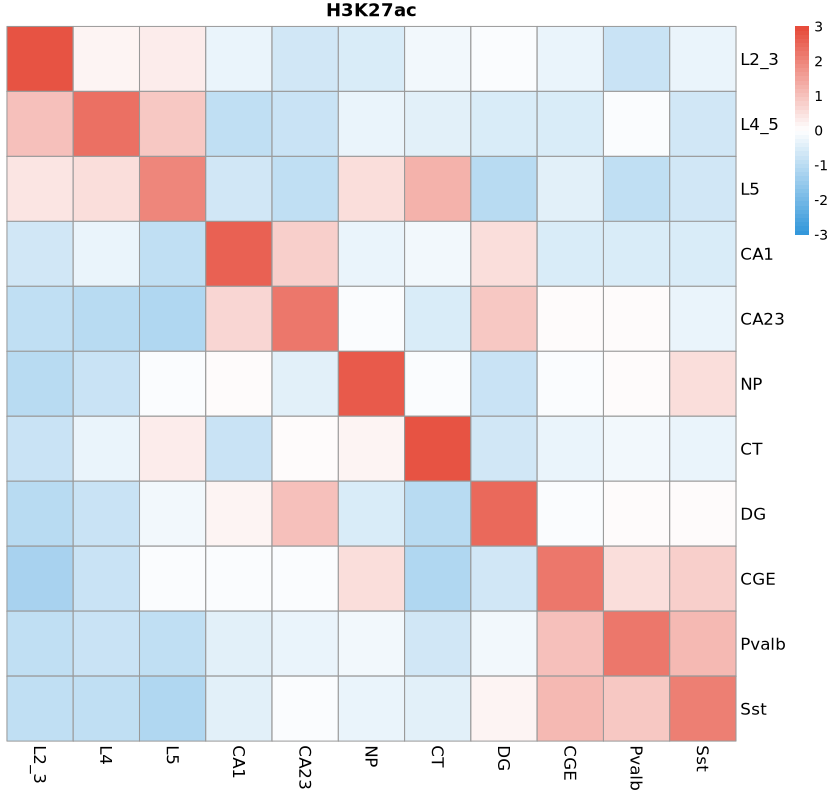

In [58]:
options(repr.plot.width = 8.4, repr.plot.height = 8, repr.plot.res = 100)
pheatmap(
  scaled_heatmap_matrix,
  cluster_rows = FALSE,
  cluster_cols = FALSE,
  color = colorRampPalette(c("#3498db", "white", "#e74c3c"))(50),
  main = "H3K27ac",
  fontsize_row = 12,
  fontsize_col = 12,
  breaks = seq(-3, 3, length.out = 51)
)

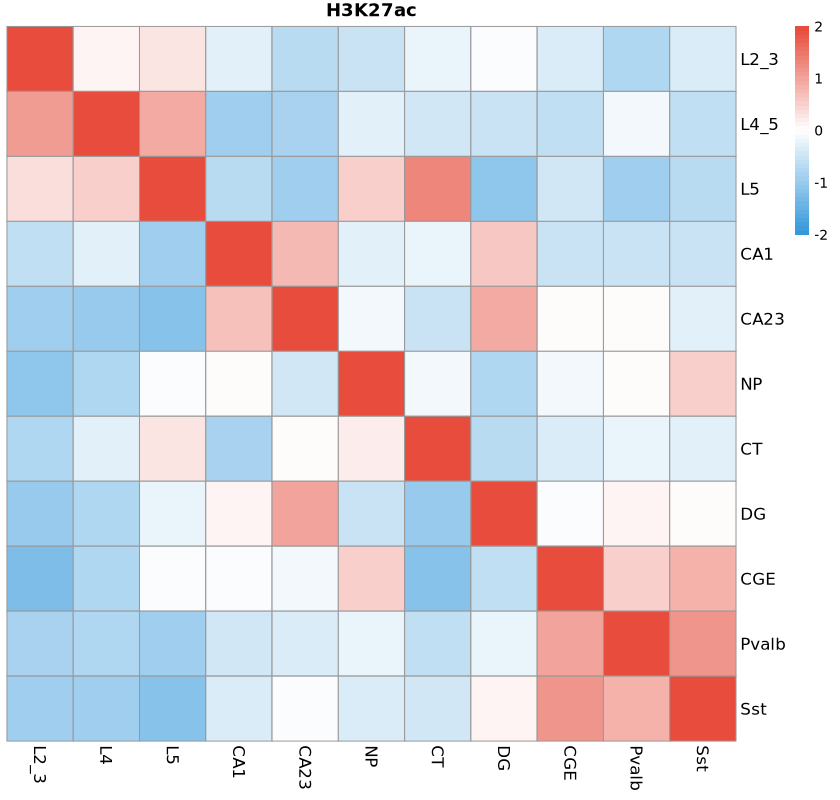

In [59]:
options(repr.plot.width = 8.4, repr.plot.height = 8, repr.plot.res = 100)
pheatmap(
  scaled_heatmap_matrix,
  cluster_rows = FALSE,
  cluster_cols = FALSE,
  color = colorRampPalette(c("#3498db", "white", "#e74c3c"))(50),
  main = "H3K27ac",
  fontsize_row = 12,
  fontsize_col = 12,
  breaks = seq(-2, 2, length.out = 51)
)

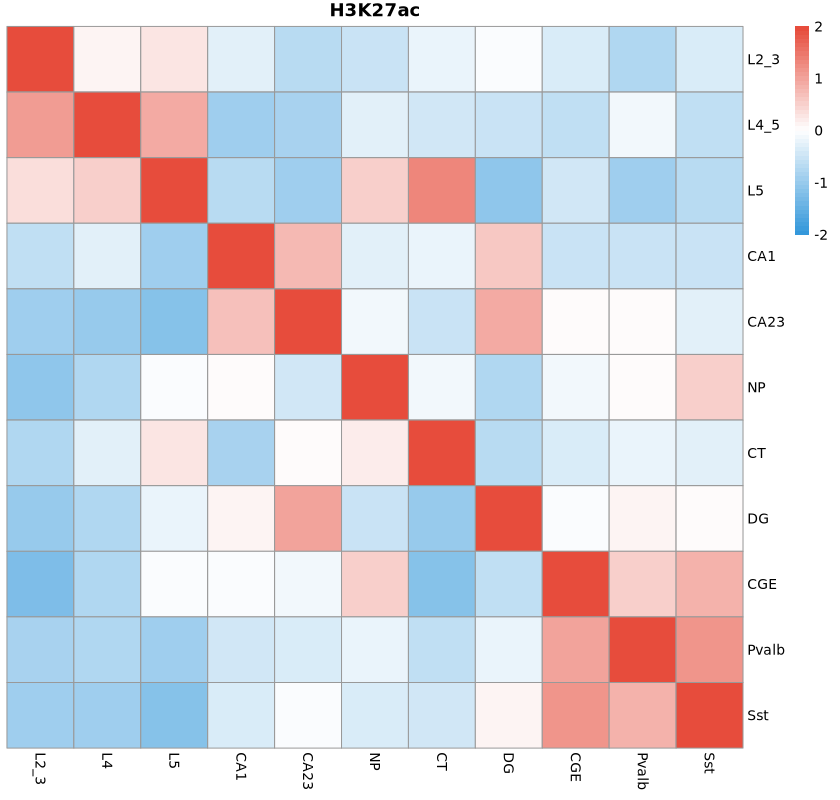

In [60]:
p1 <- pheatmap(
  scaled_heatmap_matrix,
  cluster_rows = FALSE,
  cluster_cols = FALSE,
  color = colorRampPalette(c("#3498db", "white", "#e74c3c"))(50),
  main = "H3K27ac",
  fontsize_row = 10,
  fontsize_col = 10,
  breaks = seq(-2, 2, length.out = 51)
)

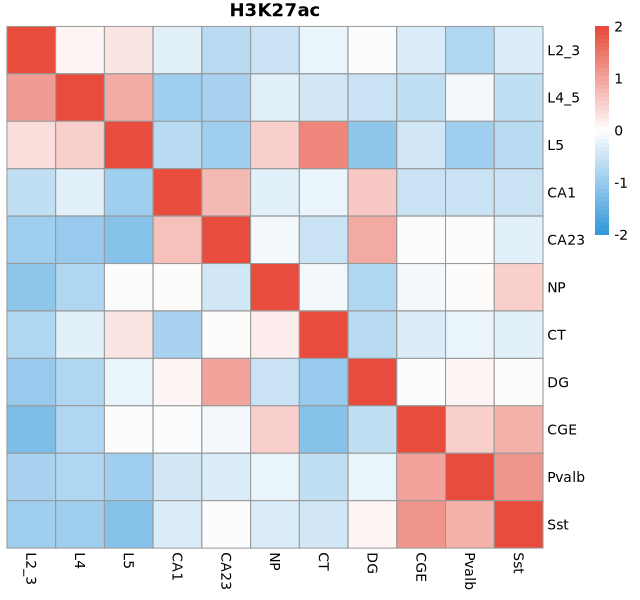

In [61]:
options(repr.plot.width = 6.4, repr.plot.height = 6, repr.plot.res = 100)
p1

In [62]:
pdf("../output/11-H3K27ac_modification_in_hyperDHMR_merge.pdf",width = 6.4,height = 6)
p1
dev.off()

png 
  2

In [ ]:
# Finished!